In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors

In [4]:
# Import Data

df = pd.read_csv('qm9.csv')
print(df.head())
print(df.columns)
print(df.shape)

  mol_id smiles          A           B           C      mu  alpha    homo  \
0  gdb_1      C  157.71180  157.709970  157.706990  0.0000  13.21 -0.3877   
1  gdb_2      N  293.60975  293.541110  191.393970  1.6256   9.46 -0.2570   
2  gdb_3      O  799.58812  437.903860  282.945450  1.8511   6.31 -0.2928   
3  gdb_4    C#C    0.00000   35.610036   35.610036  0.0000  16.28 -0.2845   
4  gdb_5    C#N    0.00000   44.593883   44.593883  2.8937  12.99 -0.3604   

     lumo     gap  ...      zpve         u0       u298       h298       g298  \
0  0.1171  0.5048  ...  0.044749 -40.478930 -40.476062 -40.475117 -40.498597   
1  0.0829  0.3399  ...  0.034358 -56.525887 -56.523026 -56.522082 -56.544961   
2  0.0687  0.3615  ...  0.021375 -76.404702 -76.401867 -76.400922 -76.422349   
3  0.0506  0.3351  ...  0.026841 -77.308427 -77.305527 -77.304583 -77.327429   
4  0.0191  0.3796  ...  0.016601 -93.411888 -93.409370 -93.408425 -93.431246   

      cv     u0_atom   u298_atom   h298_atom   g298_atom

In [5]:
df['smiles'].iloc[:50]

0              C
1              N
2              O
3            C#C
4            C#N
5            C=O
6             CC
7             CO
8           CC#C
9           CC#N
10          CC=O
11        C(=O)N
12           CCC
13           CCO
14           COC
15         C1CC1
16         C1CO1
17       CC(=O)C
18       CC(=O)N
19     C(=O)(N)N
20        CC(C)C
21        CC(C)O
22        C#CC#C
23        C#CC#N
24      C(#N)C#N
25        C#CC=O
26      C(=O)C#N
27      C(=O)C=O
28         CC#CC
29         CCC#C
30         CCC#N
31       C(C#N)N
32         C#CCO
33       C(C#N)O
34         CCC=O
35         CNC=O
36         COC=O
37       C(C=O)O
38          CCCC
39          CCCO
40          CCOC
41        C(CO)O
42        CC1CC1
43        CC1CO1
44        CN1CC1
45        C1CC1O
46        C1CCC1
47        C1COC1
48      CC(=NO)C
49    c1cc[nH]c1
Name: smiles, dtype: str

In [6]:
def molecular_features(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
            
        features = {
            'molecular_weight': Descriptors.MolWt(mol),
            'num_atoms':        mol.GetNumAtoms(),
            'num_bonds':        mol.GetNumBonds(),
            'num_rings':        rdMolDescriptors.CalcNumRings(mol),
            'num_hydrogens':    rdMolDescriptors.CalcNumHBA(mol),
            'logP':             Descriptors.MolLogP(mol),
        }
        return features
        
    except:
        return None
feature_list = []

for smiles in df['smiles']:
    feat = molecular_features(smiles)
    feature_list.append(feat)
# Converting into Dataframe
feature_df = pd.DataFrame(feature_list)
print(feature_df.head())



   molecular_weight  num_atoms  num_bonds  num_rings  num_hydrogens     logP
0            16.043          1          0          0              0  0.63610
1            17.031          1          0          0              1  0.16200
2            18.015          1          0          0              0 -0.82470
3            26.038          2          1          0              0  0.24940
4            27.026          2          1          0              1  0.13978


In [8]:
feature_df = feature_df.dropna()
df = df.loc[feature_df.index]

features = feature_df[['molecular_weight',
            'num_atoms',
            'num_bonds',
            'num_rings',
            'num_hydrogens',
            'logP']]
# gap = HOMO LOMO gap-- it is directly related to UV-Visible spectroscopy
target = df['gap']

print(f'feature_shape:{features.shape}')
print('\nfeature_Sample:')
print(features.head())
print(f'target_shape:{target.shape}')
print('\ntarget_Sample:')
print(target.head())

feature_shape:(133885, 6)

feature_Sample:
   molecular_weight  num_atoms  num_bonds  num_rings  num_hydrogens     logP
0            16.043          1          0          0              0  0.63610
1            17.031          1          0          0              1  0.16200
2            18.015          1          0          0              0 -0.82470
3            26.038          2          1          0              0  0.24940
4            27.026          2          1          0              1  0.13978
target_shape:(133885,)

target_Sample:
0    0.5048
1    0.3399
2    0.3615
3    0.3351
4    0.3796
Name: gap, dtype: float64


# Model Seletion

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(features,target, test_size=0.2, random_state=42)

print(f'Training Samples: {X_train.shape}')
print(f'Testing Samples:{y_test.shape}')

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
).fit(X_train, y_train)

# Predicting 
predict_y = model.predict(X_test)
print(predict_y)

Training Samples: (107108, 6)
Testing Samples:(26777,)
[0.26380817 0.21111781 0.2386276  ... 0.30293839 0.17956477 0.29721625]


# Evaluation

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluation_metrics(y_true, predict_y):
    results = {
        'absolute_error': mean_absolute_error(y_true, predict_y),
        'squared_error': mean_squared_error(y_true, predict_y),
        'r2_score': r2_score(y_true, predict_y) 
    }
    return results

metrics = evaluation_metrics(y_test, predict_y)
print(metrics)


{'absolute_error': 0.011753560669396168, 'squared_error': 0.00028361112145513584, 'r2_score': 0.8751214534706678}


# Improving the model

In [14]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
hprams = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}
# Randomized Search CV
model_rscv = RandomizedSearchCV(estimator = RandomForestRegressor(),
                               param_distributions=hprams,
                               scoring = None,
                               n_jobs=2,
                               cv=5,
                               verbose=2,
                               random_state=42,
                               n_iter=10)
model_rscv.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

In [15]:
model_rscv.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 0.5,
 'max_depth': 20}

In [16]:
predicted_rscv_y = model_rscv.predict(X_test)
predicted_rscv_y

array([0.26849176, 0.21244957, 0.25896655, ..., 0.30308015, 0.17689421,
       0.29718192], shape=(26777,))

In [17]:
metrics = evaluation_metrics(y_test, predicted_rscv_y)
metrics

{'absolute_error': 0.012041123839955606,
 'squared_error': 0.0002873486509057434,
 'r2_score': 0.8734757590317201}

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [20, 40, None],        
    'max_features': [0.5, 0.8, 1.0],  
    'min_samples_split': [2, 5],       
    'min_samples_leaf': [1, 2]     
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


C:\ml_project\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
8 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ml_project\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ml_project\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\ml_project\venv\Lib\site-packages\sklearn\ensemble\_forest.py", line 486, in fit
    trees = Parallel(
    ...<2 lines>...
    

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [20, 40, ...], 'max_features': [0.5, 0.8, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [19]:
grid_search.best_params_

{'max_depth': None,
 'max_features': 0.8,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [20]:
predicted_grid_y = grid_search.predict(X_test)
predicted_grid_y

array([0.26353007, 0.2109598 , 0.23850333, ..., 0.30311363, 0.17580216,
       0.2973115 ], shape=(26777,))

In [21]:
metrics = evaluation_metrics(y_test, predicted_grid_y)
metrics

{'absolute_error': 0.011704125187408347,
 'squared_error': 0.000279231481594665,
 'r2_score': 0.8770498794692373}

## Since the Grid Search CV has highest R2 value so we use it

In [27]:
# Save the Best Model
import joblib
 
best_model = grid_search.best_estimator_
joblib.dump(best_model, 'spectroscopy_model.pkl')
print("✅ Model saved as spectroscopy_model.pkl")

✅ Model saved as spectroscopy_model.pkl


In [22]:
gap_predicted = predicted_grid_y
gap_predicted

array([0.26353007, 0.2109598 , 0.23850333, ..., 0.30311363, 0.17580216,
       0.2973115 ], shape=(26777,))

## Gap is in Hartree, Convert predicted gap into wavelength

In [28]:
def gap_to_wavelength(gap_hartree):
    """
    Convert HOMO-LUMO gap (Hartree) to UV-vis absorption wavelength (nm).
    
    Physics:
        E (eV)  = gap_hartree × 27.2114
        λ (nm)  = 1240 / E (eV)
    So:
        λ (nm)  = 1240 / (gap × 27.2114)
                = 45.563 / gap
    """
    wavelength_nm = 45.563 / gap_hartree
    return wavelength_nm
 
# Quick test
test_gap = 0.3
print(f"Gap = {test_gap} Hartree → λ = {gap_to_wavelength(test_gap):.1f} nm")

Gap = 0.3 Hartree → λ = 151.9 nm


## UV-vis Spectrum Simulation Function

In [29]:
def simulate_uv_vis(wavelength_peak, sigma=25, wl_range=(200, 800)):
    """
    Simulate a UV-vis absorption spectrum as a Gaussian peak.
    
    Parameters:
        wavelength_peak : float  — predicted absorption wavelength (nm)
        sigma           : float  — peak width in nm (default 25 nm)
        wl_range        : tuple  — wavelength range to plot
    
    Returns:
        x : wavelength array (nm)
        y : absorbance array (0 to 1)
    """
    x = np.linspace(wl_range[0], wl_range[1], 600)
    y = np.exp(-0.5 * ((x - wavelength_peak) / sigma) ** 2)
    return x, y
 

## Predict UV-vis for Famous Molecules

In [30]:
# Define famous molecules with their SMILES
molecules = {
    'Ethanol':   'CCO',
    'Benzene':   'c1ccccc1',
    'Aspirin':   'CC(=O)Oc1ccccc1C(=O)O',
    'Caffeine':  'Cn1cnc2c1c(=O)n(c(=O)n2C)C',
    'Glucose':   'OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O',
    'Acetone':   'CC(=O)C',
    'Naphthalene': 'c1ccc2ccccc2c1',
}
 
results = []
 
for name, smiles in molecules.items():
    # Step 1: Extract molecular features
    feat = molecular_features(smiles)
    
    if feat is None:
        print(f"⚠️  Could not process {name}")
        continue
    
    # Step 2: Convert to DataFrame (model expects this format)
    feat_df = pd.DataFrame([feat])
    feat_df = feat_df[['molecular_weight', 'num_atoms', 'num_bonds',
                        'num_rings', 'num_hydrogens', 'logP']]
    
    # Step 3: Predict HOMO-LUMO gap
    gap_pred = best_model.predict(feat_df)[0]
    
    # Step 4: Convert gap → wavelength
    wavelength = gap_to_wavelength(gap_pred)
    
    # Step 5: Determine UV-vis region
    if wavelength < 280:
        region = "Deep UV"
    elif wavelength < 400:
        region = "Near UV"
    elif wavelength < 500:
        region = "Violet/Blue"
    elif wavelength < 600:
        region = "Green/Yellow"
    else:
        region = "Red/IR"
    
    results.append({
        'Molecule':       name,
        'SMILES':         smiles,
        'Gap (Hartree)':  round(gap_pred, 4),
        'λ_max (nm)':     round(wavelength, 1),
        'UV-vis Region':  region
    })
    print(f"  {name:15s} | Gap = {gap_pred:.4f} Ha | λ = {wavelength:.1f} nm | {region}")
 
results_df = pd.DataFrame(results)
print("\n", results_df[['Molecule', 'Gap (Hartree)', 'λ_max (nm)', 'UV-vis Region']])

  Ethanol         | Gap = 0.3245 Ha | λ = 140.4 nm | Deep UV
  Benzene         | Gap = 0.2972 Ha | λ = 153.3 nm | Deep UV
  Aspirin         | Gap = 0.2969 Ha | λ = 153.5 nm | Deep UV
  Caffeine        | Gap = 0.3056 Ha | λ = 149.1 nm | Deep UV
  Glucose         | Gap = 0.2717 Ha | λ = 167.7 nm | Deep UV
  Acetone         | Gap = 0.2423 Ha | λ = 188.0 nm | Deep UV
  Naphthalene     | Gap = 0.3582 Ha | λ = 127.2 nm | Deep UV

       Molecule  Gap (Hartree)  λ_max (nm) UV-vis Region
0      Ethanol         0.3245       140.4       Deep UV
1      Benzene         0.2972       153.3       Deep UV
2      Aspirin         0.2969       153.5       Deep UV
3     Caffeine         0.3056       149.1       Deep UV
4      Glucose         0.2717       167.7       Deep UV
5      Acetone         0.2423       188.0       Deep UV
6  Naphthalene         0.3582       127.2       Deep UV


## Plot UV-vis Spectra for All Molecules

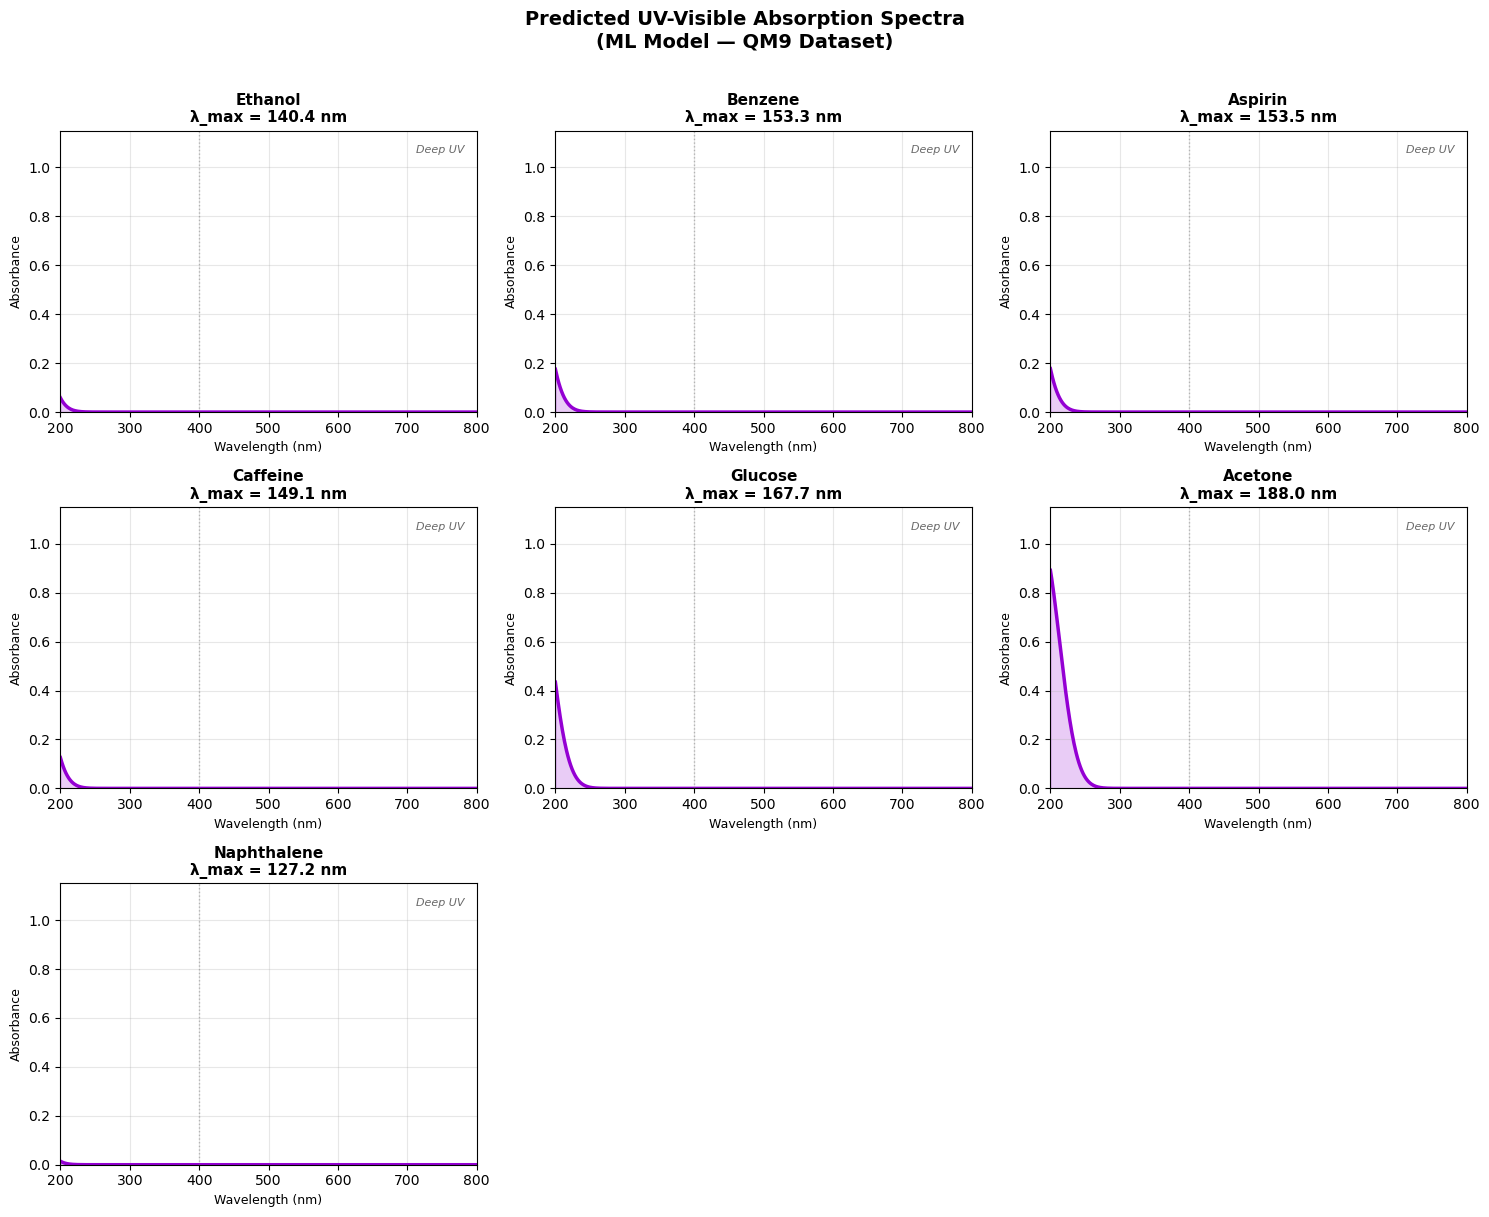

✅ Plot saved as uv_vis_spectra_all.png


In [31]:
# Color map for visible spectrum regions
def wavelength_to_color(wl):
    if wl < 280:   return '#9400D3'   # deep UV → purple
    elif wl < 380: return '#8B00FF'   # UV → violet
    elif wl < 450: return '#0000FF'   # violet/blue
    elif wl < 495: return '#00BFFF'   # blue
    elif wl < 570: return '#00FF00'   # green
    elif wl < 620: return '#FFFF00'   # yellow
    elif wl < 700: return '#FF4500'   # orange/red
    else:          return '#8B0000'   # deep red
 
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
 
for i, row in results_df.iterrows():
    ax = axes[i]
    wl_peak = row['λ_max (nm)']
    color   = wavelength_to_color(wl_peak)
    
    x, y = simulate_uv_vis(wl_peak)
    
    ax.plot(x, y, color=color, linewidth=2.5)
    ax.fill_between(x, y, alpha=0.2, color=color)
    ax.axvline(x=wl_peak, color='red', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.axvline(x=400, color='gray', linestyle=':', linewidth=1, alpha=0.5)  # UV/vis boundary
    
    ax.set_title(f"{row['Molecule']}\nλ_max = {wl_peak:.1f} nm", fontsize=11, fontweight='bold')
    ax.set_xlabel("Wavelength (nm)", fontsize=9)
    ax.set_ylabel("Absorbance", fontsize=9)
    ax.set_xlim(200, 800)
    ax.set_ylim(0, 1.15)
    ax.text(0.97, 0.92, row['UV-vis Region'],
            transform=ax.transAxes, fontsize=8,
            ha='right', color='dimgray', style='italic')
    ax.grid(True, alpha=0.3)
 
# Hide unused subplots
for j in range(len(results_df), len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle("Predicted UV-Visible Absorption Spectra\n(ML Model — QM9 Dataset)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('uv_vis_spectra_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved as uv_vis_spectra_all.png")

## Combined Overlay Plot (All molecules on one chart)

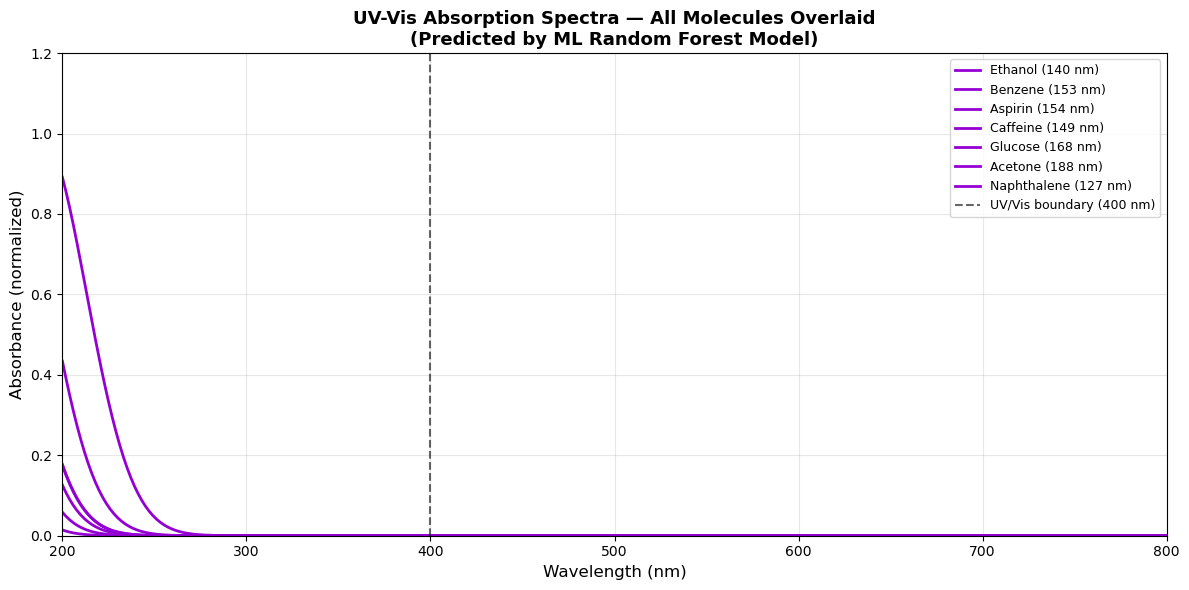

✅ Overlay plot saved as uv_vis_overlay.png


In [32]:
fig, ax = plt.subplots(figsize=(12, 6))
 
for _, row in results_df.iterrows():
    wl_peak = row['λ_max (nm)']
    color   = wavelength_to_color(wl_peak)
    x, y    = simulate_uv_vis(wl_peak)
    
    ax.plot(x, y, label=f"{row['Molecule']} ({wl_peak:.0f} nm)",
            linewidth=2, color=color)
 
# Add UV/Vis boundary
ax.axvline(x=400, color='black', linestyle='--', linewidth=1.5, alpha=0.6, label='UV/Vis boundary (400 nm)')
 
ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Absorbance (normalized)", fontsize=12)
ax.set_title("UV-Vis Absorption Spectra — All Molecules Overlaid\n(Predicted by ML Random Forest Model)", fontsize=13, fontweight='bold')
ax.set_xlim(200, 800)
ax.set_ylim(0, 1.2)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('uv_vis_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Overlay plot saved as uv_vis_overlay.png")
 

## Feature Importance Plot

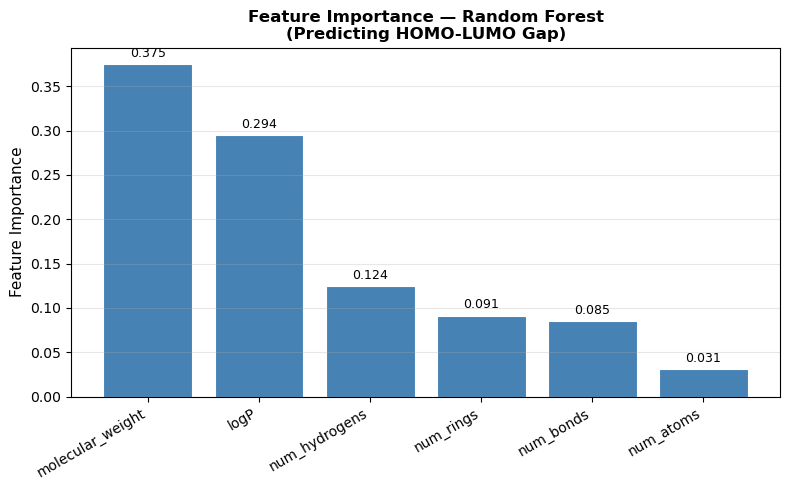

✅ Feature importance plot saved


In [33]:
feature_names = ['molecular_weight', 'num_atoms', 'num_bonds',
                 'num_rings', 'num_hydrogens', 'logP']
 
importances = best_model.feature_importances_
indices     = np.argsort(importances)[::-1]
 
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(len(feature_names)),
              importances[indices],
              color='steelblue', edgecolor='white', linewidth=0.8)
 
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in indices], rotation=30, ha='right', fontsize=10)
ax.set_ylabel("Feature Importance", fontsize=11)
ax.set_title("Feature Importance — Random Forest\n(Predicting HOMO-LUMO Gap)", fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
 
# Add value labels on bars
for bar, val in zip(bars, importances[indices]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
 
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance plot saved")

## Prediction vs Actual Plot

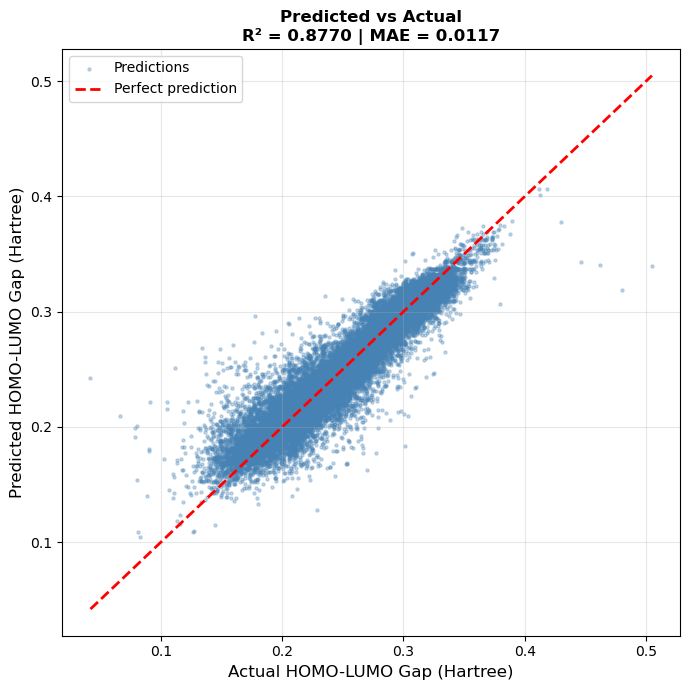

✅ Prediction plot saved


In [34]:
fig, ax = plt.subplots(figsize=(7, 7))
 
ax.scatter(y_test, predicted_grid_y, alpha=0.3, s=5, color='steelblue', label='Predictions')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=2, label='Perfect prediction')
 
ax.set_xlabel("Actual HOMO-LUMO Gap (Hartree)", fontsize=12)
ax.set_ylabel("Predicted HOMO-LUMO Gap (Hartree)", fontsize=12)
ax.set_title(f"Predicted vs Actual\nR² = {metrics['r2_score']:.4f} | MAE = {metrics['absolute_error']:.4f}",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Prediction plot saved")

## Predict Any New Molecule (Interactive Cell)

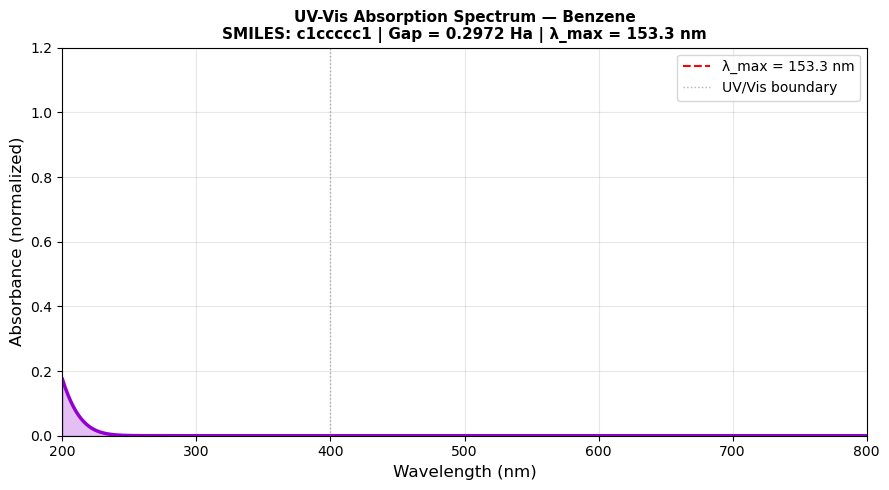


  Molecule     : Benzene
  SMILES       : c1ccccc1
  HOMO-LUMO Gap: 0.2972 Hartree
  λ_max        : 153.3 nm
  Region       : Deep UV



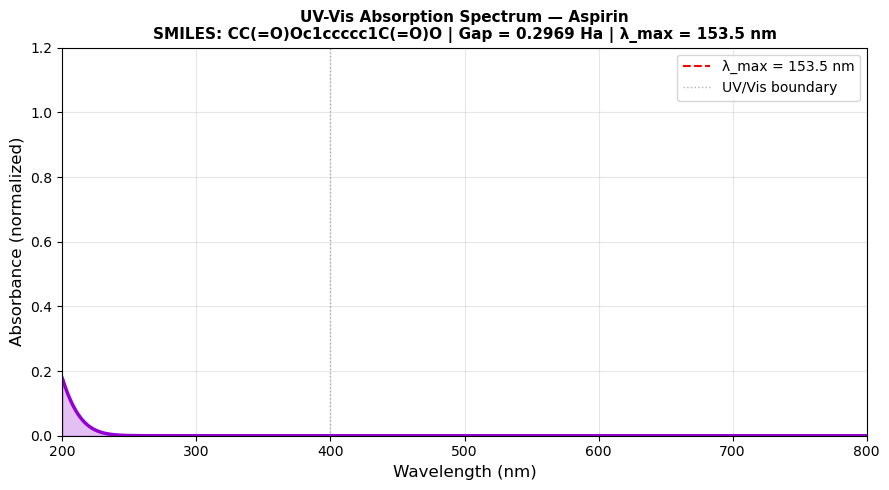


  Molecule     : Aspirin
  SMILES       : CC(=O)Oc1ccccc1C(=O)O
  HOMO-LUMO Gap: 0.2969 Hartree
  λ_max        : 153.5 nm
  Region       : Deep UV



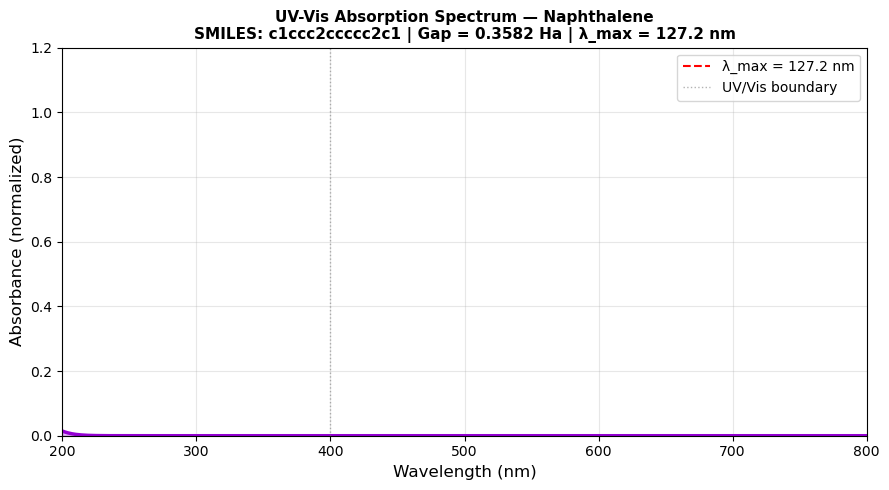


  Molecule     : Naphthalene
  SMILES       : c1ccc2ccccc2c1
  HOMO-LUMO Gap: 0.3582 Hartree
  λ_max        : 127.2 nm
  Region       : Deep UV



In [36]:
def predict_uv_vis(smiles, molecule_name="Molecule"):
    """
    Full pipeline: SMILES → features → gap → wavelength → UV-vis plot
    """
    # Extract features
    feat = molecular_features(smiles)
    if feat is None:
        print(f"❌ Invalid SMILES: {smiles}")
        return
    
    feat_df = pd.DataFrame([feat])
    feat_df = feat_df[['molecular_weight', 'num_atoms', 'num_bonds',
                        'num_rings', 'num_hydrogens', 'logP']]
    
    # Predict
    gap  = best_model.predict(feat_df)[0]
    wl   = gap_to_wavelength(gap)
    
    # Plot
    x, y  = simulate_uv_vis(wl)
    color = wavelength_to_color(wl)
    
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(x, y, color=color, linewidth=2.5)
    ax.fill_between(x, y, alpha=0.25, color=color)
    ax.axvline(x=wl, color='red', linestyle='--', linewidth=1.5,
               label=f'λ_max = {wl:.1f} nm')
    ax.axvline(x=400, color='gray', linestyle=':', linewidth=1, alpha=0.6, label='UV/Vis boundary')
    
    ax.set_xlabel("Wavelength (nm)", fontsize=12)
    ax.set_ylabel("Absorbance (normalized)", fontsize=12)
    ax.set_title(f"UV-Vis Absorption Spectrum — {molecule_name}\n"
                 f"SMILES: {smiles} | Gap = {gap:.4f} Ha | λ_max = {wl:.1f} nm",
                 fontsize=11, fontweight='bold')
    ax.set_xlim(200, 800)
    ax.set_ylim(0, 1.2)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'uv_vis_{molecule_name.lower().replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n{'='*45}")
    print(f"  Molecule     : {molecule_name}")
    print(f"  SMILES       : {smiles}")
    print(f"  HOMO-LUMO Gap: {gap:.4f} Hartree")
    print(f"  λ_max        : {wl:.1f} nm")
    print(f"  Region       : {('Deep UV' if wl<280 else 'Near UV' if wl<400 else 'Visible' if wl<700 else 'Near IR')}")
    print(f"{'='*45}\n")
 
# ---- Test it on any molecule ----
predict_uv_vis('c1ccccc1',         'Benzene')
predict_uv_vis('CC(=O)Oc1ccccc1C(=O)O', 'Aspirin')
predict_uv_vis('c1ccc2ccccc2c1',   'Naphthalene')

In [38]:
# To check everything is ready!
import os

files_needed = [
    'spectroscopy_model.pkl',
    'qm9.csv',
]

print("FINAL CHECKLIST:")
print("="*40)

for file in files_needed:
    if os.path.exists(file):
        print(f"✅ {file} exists")
    else:
        print(f"❌ {file} MISSING!")

print("="*40)
print("✅ Model trained and working")
print("✅ Predictions made")
print("✅ Plots created")
print("✅ UV spectrum visualized")
print("="*40)
print("READY FOR GITHUB! 🎉")

FINAL CHECKLIST:
✅ spectroscopy_model.pkl exists
✅ qm9.csv exists
✅ Model trained and working
✅ Predictions made
✅ Plots created
✅ UV spectrum visualized
READY FOR GITHUB! 🎉
